In [2]:
import importlib
import python_modules.Results
import python_modules.plot_res
importlib.reload( python_modules.Results )
importlib.reload( python_modules.plot_res )
from  python_modules.Results  import Results
import python_modules.plot_res as p
import itertools
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn

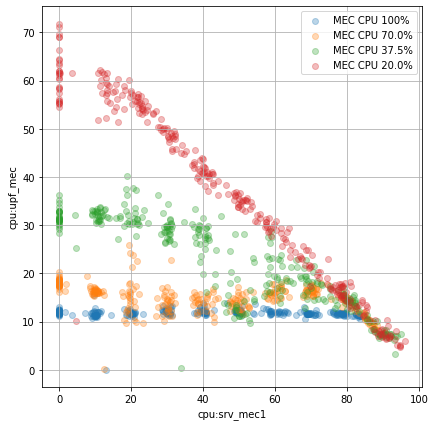

In [7]:
# SCATTER PLOT - SCENARIO 2
colors_it = itertools.cycle( ["C0","C1","C2","C3"] )
fig, ax   = plt.subplots(nrows=1, ncols=1, figsize=(7,7) )

hcpu = [1, 0.7, 0.375, 0.2]
idx  = [1,   5,     1,   1]
# hcpu = [1]
# idx  = [1]
for i in range(len(hcpu)):
    c = next(colors_it)
    res = Results( f'results/PerfHOST_scen3b_tcp_mec_hostcpu{hcpu[i]}.json', load=True )
    df_sum, _ = res.df_iperf_bwt()
    res.df = res.df.join( df_sum, how="outer" )
    df = res.df

    col = 'cpu:mec_host'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll
    
    col = 'cpu:srv_mec2'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll
    
    col = 'mec_host:ogstun_recv'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll

    col = 'iperf:ue0:bwt:sum'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll

    ax.scatter( df["cpu:srv_mec1"] , df["cpu:upf_mec"] , label=f"MEC CPU {hcpu[i]*100}%" , color=c, alpha=0.3)

ax.set_xlabel( "cpu:srv_mec1" )
ax.set_ylabel( "cpu:upf_mec" )
ax.grid(visible=True)
ax.legend()
ax.set_box_aspect(1)


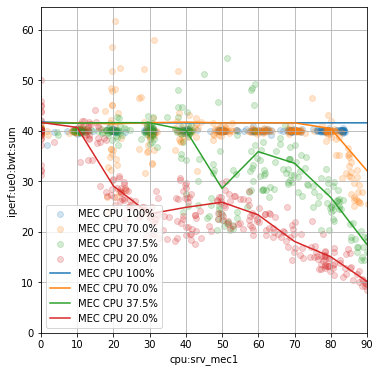

In [9]:
# FINAL FIGURE srv_mec2 VS. MEC Throughput

from scipy.interpolate import UnivariateSpline, CubicSpline, InterpolatedUnivariateSpline
from scipy import interpolate
import copy

colors_it = itertools.cycle( ["C0","C1","C2","C3"] )

fig1, ax1   = plt.subplots( nrows=1, ncols=1, figsize=(6,6) )
final_x = []
final_y = []

hcpu = [1, 0.7, 0.375, 0.2]
idx  = [1,   5,     1,   1]
for i in [0,1,2,3]:
    c = next(colors_it)

    res = Results( f'results/PerfHOST_scen3b_tcp_mec_hostcpu{hcpu[i]}.json' , load=True )
    df_sum, _ = res.df_iperf_bwt()
    res.df = res.df.join( df_sum, how="outer" )
    df = res.df

    col = 'iperf:ue0:bwt:sum'
    roll = df[col].rolling( 10 , center=True ).mean()
    df[col+'_roll'] = roll
    col = 'mec_host:ogstun_recv'
    roll = df[col].rolling( 5, center=True ).mean()
    df[col+'_roll'] = roll
    col = 'cpu:srv_mec1'
    roll = df[col].rolling( 5 , center=True ).mean()
    df[col+'_roll'] = roll

    p.plot_scatter( df, ax1, 'cpu:srv_mec1', "iperf:ue0:bwt:sum", "cpu:srv_mec1", "iperf:ue0:bwt:sum",label=f"MEC CPU {hcpu[i]*100}%", color=c, alpha=0.2)

    ### ADD average and std by splitting the srv_mec2 in bins
    # thr_col = 'iperf:ue0:bwt:sum_roll'
    # thr_col = 'iperf:ue0:bwt:sum'
    thr_col = "mec_host:ogstun_recv"

    cpu_col = 'cpu:srv_mec1_roll'
    # cpu_col = 'cpu:srv_mec1'
    dftmp = df[[ cpu_col,thr_col ]]

    bins_int = [-5,5,15,25,35,45,55,65,75,85,95]
    bins = pd.cut(dftmp[cpu_col], bins_int)
    dftmp = dftmp.groupby(bins).agg(["mean", "std"])
    dftmp["x_val"] = [x+5 for x in bins_int[0 : dftmp.shape[0] ]]

    # display(dftmp)
    dftmp = dftmp.dropna()
    x = dftmp["x_val"]
    y = dftmp[thr_col]["mean"]

    final_x.append( list(x) )
    final_y.append( list(y) )

# display(final_x)
# print(final_y)
final_x_c = copy.deepcopy(final_x)
final_y_c = copy.deepcopy(final_y)
final_x_c[0].append(90)
final_y_c[0].append(final_y[0][-1])
final_x_c.append(final_x_c[0])
final_y_c.append([0]*len(final_x_c[0]))
# display(final_x_c)
# print(final_y_c)

for i in [0,1,2,3]:
    ax1.plot( final_x_c[i] , final_y_c[i] , label=f"MEC CPU {hcpu[i]*100}%")
#     ax1.fill_between(final_x_c[i], final_y_c[i], final_y_c[i+1]  , alpha = 0.2)

ax1.legend()
ax1.grid(visible=True)
ax1.set_xlim(0,90)
ax1.set_ylim(bottom=0)
ax1.set_xlabel("cpu:srv_mec1")
ax1.set_ylabel("iperf:ue0:bwt:sum")
ax1.legend()
ax1.set_box_aspect(1)



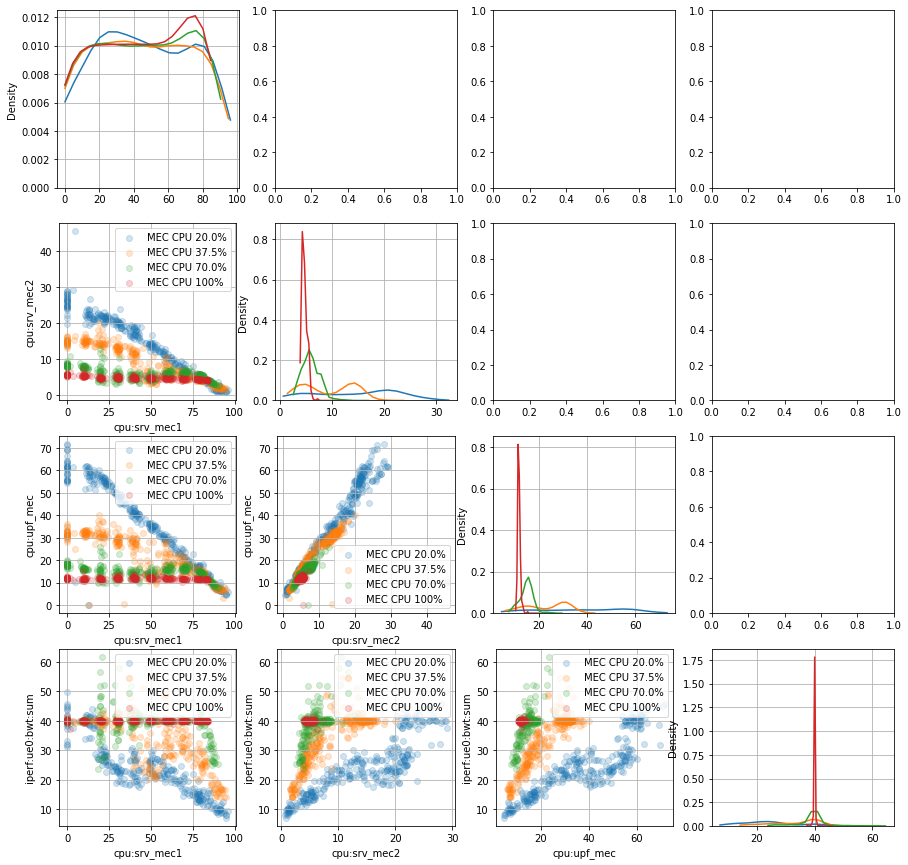

In [3]:
# Variables relation overview - SCENARIO 2

colors_it = itertools.cycle( ["C0","C1","C2","C3"] )
# fig, ax   = plt.subplots(nrows=1, ncols=2, figsize=(15,7) )

fig1, ax1   = plt.subplots( nrows=4, ncols=4, figsize=(15,15) )#,sharex=True ,sharey=True )

# hcpu = [1, 0.7, 0.375, 0.2]
# idx  = [1,   5,     1,   1]
hcpu = [0.2, 0.375, 0.7, 1]
idx  = [1,   1,     5,   1]
# hcpu = [1]
# idx  = [1]
# hcpu = [0.7]
# idx  = [5]
# hcpu = [0.375]
# hcpu = [0.2]
# idx  = [1]
cols = [ 'cpu:srv_mec1','cpu:srv_mec2','cpu:upf_mec','iperf:ue0:bwt:sum' ]
# cols = [ 'cpu:srv_mec1','cpu:upf_mec','cpu:srv_mec2','mec_host:ogstun_recv' ]

for i in range(len(hcpu)):

    c = next(colors_it)
    res = Results( f'results/PerfHOST_scen3b_tcp_mec_hostcpu{hcpu[i]}.json', load=True )
    df_sum, _ = res.df_iperf_bwt()
    res.df = res.df.join( df_sum, how="outer" )
    df = res.df
    df = df.dropna()

    for row in range( len(cols) ):
        minv = min(df[cols[row]].values)-0
        maxv = max(df[cols[row]].values)+5
        interval = (maxv-minv)/20
        df[cols[row]].plot.density( ax=ax1[row,row], color=c, ind=[a for a in np.arange(minv,maxv,interval)])
        ax1[row,row].grid(visible=True)

        for col in range( len(cols) ):
            if col >= row:
                continue
            p.plot_scatter( res.df, ax1[row][col], cols[col],cols[row] , cols[col],cols[row] , label=f"MEC CPU {hcpu[i]*100}%" , color=c, alpha=0.2)

for row in range( len(cols) ):
    ax1[row,row].set_ylim(bottom=0,top=None)

# for row in range( len(cols) ):
    # ax1[row,0].set_xlim(left=0,right=30)
    # ax1[row,1].set_xlim(left=0,right=80)
    # ax1[row,2].set_xlim(left=0,right=100)
